In [19]:
import rebound
import numpy as np
import random
import matplotlib.pyplot as plt

# We add the BHs
M_1 = 3e9
q = 1
M_2 = q * M_1
M_total = M_1 + M_2

# Schwarzchild radius
c = 2.99792458e8 * 6.68459e-12 * (3600 * 24 * 365.2425)
G = 6.674e-11 * (6.68459e-12) ** 3 * (3600 * 24 * 365.2425) ** 2
M = M_1 * 1.989e30
R_sch = 2 * G * M / c**2

print(f'The Schwarzchild radius is {R_sch} ua')

#Sim parameters
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years/N_frames
N_masses =20
M_spike = np.linspace(0.01, 0.4, N_masses)*M_1
avg_distance_tot = []

The Schwarzchild radius is 59.238711673042346 ua


In [20]:
for m in range(len(M_spike)):
    # Create an empty universe
    sim = rebound.Simulation()
    sim.units = ('yr', 'AU', 'Msun')
    sim.add(m=M_1)
    sim.add(m = M_2, a = 206265)

    # We define the BH
    black_hole_1 = sim.particles[0]
    black_hole_2 = sim.particles[1]

    # Define the DM spike
    N_particles = 80
    M_spike_total = M_spike[m]
    m_single_dm = M_spike_total / N_particles
    radius_spike = 400000
    bh_distance = []

    # Shifts the entire reference frame so the COM is at the origin
    sim.move_to_com()

    print(f"Generating {N_particles} DM particles in the spike with mass {m_single_dm:.2e} Msun each...")
    random.seed(0)

    for i in range(N_particles):
        # pick a random distance to the black hole
        r = random.uniform(1000, radius_spike)
        
        # Pick random angles to make it a 3D sphere
        random_tilt = random.uniform(0, np.pi)
        random_phi = random.uniform(0, 2*np.pi)
        
        x = r * np.sin(random_tilt) * np.cos(random_phi)
        y = r * np.sin(random_tilt) * np.sin(random_phi)
        z = r * np.cos(random_tilt)
        # Velocity for rotating the CoM
        v_circ = np.sqrt(sim.G * M_total / r)
        
        v_x = -v_circ * np.sin(random_tilt)
        v_y = v_circ * np.cos(random_tilt)
        
        #Add the particles as rotating the CoM
        
        # Add the particles
        sim.add(m = m_single_dm, x=x, y=y, vx=v_x, vy = v_y)

    # We give a collision radius to the BH
    sim.particles[0].r = R_sch
    sim.particles[1].r = R_sch

    # Turn the rebound collision detector
    sim.collision = "direct"

    # Tell rebound that if there is a collision then merge the particles
    sim.collision_resolve = "merge"

    for i in range(N_frames):
        next_time = sim.t + Delta_time
        sim.integrate(next_time)
        
        # Print progress so you know it hasn't frozen
        if i % 100 == 0:
            print(f"Rendered frame {i} / {N_frames}")
            
        # Save the distances between blackhole
        bh_distance.append(black_hole_1 ** black_hole_2)
        
    # We convert to parsec
    bh_distance = np.array(bh_distance) / 206265

    avg_distance = [bh_distance[0]]
    for i in range(1, len(bh_distance)):
        a = min(i, 50)
        sum = 0
        for g in range(int(a)):
            sum += bh_distance[i - g]
        
        avg_distance_new = sum / a
        avg_distance.append(avg_distance_new)
        
    avg_distance_tot.append(avg_distance)
    print(f'Simulation for Mass M={M_spike[m]} completed')

Generating 80 DM particles in the spike with mass 3.75e+05 Msun each...
Rendered frame 0 / 600


KeyboardInterrupt: 

IndexError: list index out of range

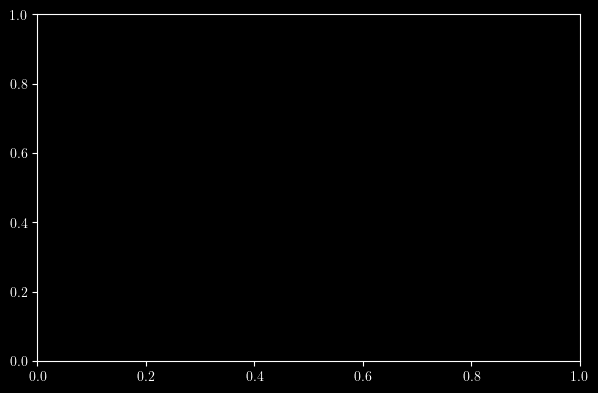

In [ ]:
# --- GLOBAL PLOT SETTINGS (Publication Quality) ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 12,
})

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- GLOBAL PLOT SETTINGS --- 
fig1, ax1d = plt.subplots(figsize=(7, 4.5)) # Made slightly wider to fit the colorbar

# 1. Set up the Colormap (Plasma looks amazing on dark backgrounds)
cmap = cm.plasma 
norm = mcolors.Normalize(vmin=min(M_spike), vmax=max(M_spike))

# 2. Plot the lines using the colormap
for i in range(len(M_spike)):
    # Grab the specific color for this mass
    line_color = cmap(norm(M_spike[i])) 
    
    # Plot without a label (since the colorbar will explain it)
    ax1d.plot(t_array, avg_distance_tot[i], color=line_color, linewidth=2)

# 3. Format the Axes
ax1d.set_xlabel('Time (yr)')
ax1d.set_ylabel('Distance between the BHs (pc)')
ax1d.set_ylim(0, 1.05)

# 4. Create and attach the Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # This is a matplotlib quirk required for colorbars
cbar = fig1.colorbar(sm, ax=ax1d)
cbar.set_label('Spike Mass Fraction ($M_{sp} / M_{BH}$)', fontsize=11)

plt.tight_layout()
fig1.savefig(f'Distance_vs_time_scanning_Mspike_N={N_particles}_Nscanning={N_masses}.pdf')
plt.show()

In [ ]:
np.savez(f'datos_distancia_vs_time_scanning_Mspike_N={N_particles}_Nscanning={N_masses}.npz', avg_distance_tot = avg_distance_tot)